# **1. EfficientNet-B0 구현 (문서가 기니 목차를 적극적으로 활용하세요!)**

## **1-1. EfficientNet-B0를 구현하게 된 동기**
다양한 학습 전략을 실험하고 싶었지만 모델 학습에 소요되는 시간이 상당해 반복적인 실험에는 무리가 있었습니다. 비교적 가벼우면서도 성능이 좋은 모델이 있었으면 했고, 탐색 과정에서 ResNet-50 대비 적은 파라미터와 경쟁력 있는 성능을 가진 EfficientNet-B0를 발견할 수 있었습니다.

해당 모델에 대해선 이전에 들어본 경험이 있었으며, 효율적인 모델 스케일링 방식을 제안한다는 점에 흥미를 느껴 이번에 구현하기로 결정했습니다.

## **2. 구현에 참고한 논문**
**[1]   EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks**
([논문 링크](https://arxiv.org/abs/1905.11946))

이름 그대로 EfficientNet을 소개한 논문입니다. Neural Architecture Search(NAS)로 최적의 모델 구조를 발굴하고, depth와 width, resolution을 체계적이고 종합적으로 스케일링해 모델 성능을 향상시킨 점이 인상 깊었습니다.

또한 EfficientNet-B0부터 B7까지 다양한 모델을 제시하며 타 모델들과 이미지 분류 정확도, 추론 시간, 파라미터 수, FLOP 등을 비교하는데, 테이블과 그래프 시각화가 정말 잘 되어 있어 이해하기 편했습니다. 멋진 논문이었습니다.

**[2] MnasNet: Platform-Aware Neural Architecture Search for Mobile** ([논문 링크](https://arxiv.org/abs/1807.11626))

EfficientNet 모델 패밀리의 백본이 되는 EfficientNet-B0는 어떻게 설계된 걸까요? 바로 이 논문에서 제안한 방법론을 활용했다고 합니다. EfficientNet 논문에서도 해당 방법론을 간략히 다루고 있기 때문에 보다 자세한 내용이 궁금하시면 이 논문을 보면 될 것 같습니다.

EfficientNet의 MBConv Block이 궁금하신 분들도 이 논문을 참고하시면 될 것 같습니다.

**[3] MobileNetV2: Inverted Residuals and Linear Bottlenecks** ([논문 링크](https://arxiv.org/abs/1801.04381))

Inverted Bottleneck Residual block의 구조와 개념을 이해할 때 참고한 논문입니다. 2번 논문과 함께 구현에 많은 도움이 되었습니다.

초반에 직관적으로 이해하기 어려운 내용이 일부 있었습니다. 읽으면서 아직 공부가 더 필요한 것 같다고 느꼈습니다.

**[4] Squeeze-and-Excitation Networks** ([논문 링크](https://arxiv.org/abs/1709.01507))

SE Block 구현을 위해 참고한 논문입니다. 메커니즘이 약간 Attention과 유사해서 흥미로웠습니다. Attention에서 각 입력 간 관계를 학습하고 가중치를 주는 것처럼, SE Block에서도 이와 유사하게 입력 피처 맵의 통계량 간 관계를 학습하고 이를 기반으로 가중치를 계산하는 과정이 있었습니다. 읽으면서 '만약 CNN 전용 Attention이 있다면 이런 느낌이지 않을까?' 하는 상상을 했습니다. 재밌는 논문이었습니다.

## **1-3. 구현 및 모델 학습 후기**

EfficientNet-B0를 구현하고 학습을 진행했으나, 초기에는 기대한 만큼의 결과를 얻지 못했습니다.

- **(25.09 실험)**  
ResNet-50 대비 파라미터 수가 1/5 이고 (25.5M -> 5.3M) FLOP이 1/10 (4.1B -> 0.39B)인 점을 고려해 학습 시간이 크게 단축될 것으로 기대했습니다. 그러나 실제로는 epoch당 학습 시간이 약 10% 단축되는 데 그쳤습니다. 이후 모델 학습이 오래 걸리는 이유를 알아본 결과, Depthwise Convolution이 생각보다 연산 비용이 높다고 합니다. 이로 인해 학습 시간 단축이 기대한 만큼 되지 않은 것으로 이해하고 있습니다.

- **(26.01 실험)**  
DataLoader의 num_workers 설정을 조정한 이후 재학습을 진행한 결과, EfficientNet-B0의 epoch당 학습 시간은 0.6분, ResNet-50은 약 1분으로 측정되었습니다. 이를 통해 EfficientNet-B0가 ResNet-50 대비 학습 시간이 약 40% 단축되었음을 확인할 수 있었습니다. 25년 9월에 처음 구현하고 실험할 당시 모델이 가진 이점과 효율성을 충분히 끌어내기엔 제가 너무 미숙하고 기초가 부족했던 것 같습니다.

- **성능 비교**  
EfficientNet-B0 또한 ResNet-50과 마찬가지로 VGG16-bn보다 높은 성능을 보이지는 않았습니다. 비교적 작은 규모의 데이터셋을 사용한 환경에서 모델 복잡도에 따른 오버피팅의 영향을 받은 것으로 보입니다. 향후 ImagNet으로 사전 훈련된 모델을 파인튜닝하는 식으로 이들의 성능을 다시 비교해보려고 합니다. (구현6 레포지토리 참고)

## **1-4. 모델 구현**
Pytorch에 구현된 모델과 동일한 구조, 동일한 파라미터 수를 가지는 EfficientNet-B0을 구현했습니다.  

In [ ]:
import torch
import torch.nn as nn
from torchvision.ops import StochasticDepth

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, norm='bn', act_func='SiLU'):
        # ReLU 대신 SiLU를 활성 함수로 사용하는 점이 지금까지 구현한 모델들과 다른 점입니다!

        super().__init__()

        layers = []
        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False))

        if norm == 'bn':
            layers.append(nn.BatchNorm2d(out_channels))

        if act_func == 'SiLU':
            layers.append(nn.SiLU())
        elif act_func == 'ReLU':
            layers.append(nn.ReLU())
        else:
            pass

        self.layers = nn.Sequential(*layers)

    def forward(self,x):
        x = self.layers(x)
        return x

In [ ]:
class DWConvBlock(nn.Module):
    def __init__(self, in_channels, kernel_size=3, stride=1, padding=1, norm='bn', act_func='SiLU'):
        # nn.Conv2d에 groups 설정만 하면 됩니다! Depthwise Conv가 생각보다 계산이 오래 걸린다고 합니다.

        super().__init__()

        layers = []
        layers.append(nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding, bias=False, groups=in_channels))

        if norm == 'bn':
            layers.append(nn.BatchNorm2d(in_channels))

        if act_func == 'SiLU':
            layers.append(nn.SiLU())
        elif act_func == 'ReLU':
            layers.append(nn.ReLU())
        else:
            pass

        self.layers = nn.Sequential(*layers)

    def forward(self,x):
        x = self.layers(x)
        return x

In [ ]:
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction_ratio=4, act_func='SiLU'):
        # SE : Squeeze-and-Excitation의 줄임말
        # Attention에서 각 입력 간 관계를 학습하고 가중치를 주듯이, SEBlock에서도 입력으로 들어온 피쳐 맵의 통계량 간 관계를 학습하고 이를 바탕으로 가중치를 줍니다.

        super().__init__()

        assert in_channels % reduction_ratio == 0, "in_channels is not divisible by reduction_ratio"

        layers = []

        layers.append(nn.AdaptiveAvgPool2d(1))
        layers.append(nn.Conv2d(in_channels, in_channels//reduction_ratio, 1))

        if act_func == 'SiLU':
            layers.append(nn.SiLU())
        elif act_func == 'ReLU':
            layers.append(nn.ReLU())
        else:
            pass

        layers.append(nn.Conv2d(in_channels//reduction_ratio, in_channels, 1))
        layers.append(nn.Sigmoid())

        self.layers = nn.Sequential(*layers)

    def forward(self,x):
        s = self.layers(x)
        x = s * x
        return x

In [ ]:
class MBConv(nn.Module):
    def __init__(self, in_channels, out_channels, expansion_rate, kernel_size, stride, act_func='SiLU', se=True, reduction_ratio=4, drop_prob=0):
        # Stochastic Depth: dropout이 일부 뉴런의 출력을 끈다면 Stochastic Depth는 일부 layer의 출력을 끕니다. dropout을 layer 단위로 적용한다고 보시면 될 것 같아요.
        #                   출력이 꺼진 layer는 이전 레이어의 출력을 skip connection으로 그대로 가져와 자신의 출력으로 내보냅니다.
        #                   따라서 skip connection이 없는 layer에는 적용하지 않았습니다. 궁금하시면 skip connection이 없는 layer에도 적용해보세요. 모델 성능은.. 50% 대에서 머뭅니다 ^^..

        # DWconv: Depthwise Convolution layer로 1x1 Conv와 같이 사용함으로써 기존의 Conv2d의 역할을 어느 정도 대체합니다. 파라미터 수가 적어 경량화에 유리하다고 합니다.
        #         여기서 DWConv와 1x1 Conv의 역할은 각각 self.DWConv와 self.Conv2가 맡고 있습니다.
        #         ResNet과 달리 Bottelneck에서 input channel이 확장되는 Inverted Bottleneck 구조를 가지고 있습니다.

        # Shortcut: 그냥 Identity mapping. stride가 1이 아니어서 feature map의 사이즈가 변하거나 input과 output의 channel이 맞지 않는 경우에는 사용하지 않습니다.
        #           오로지 "그대로 더할 수 있을 때만" 사용합니다.
        # Shortcut 이후: ResNet-50 에서는 Shortcut 이후에 ReLU를 적용했지만 MBConv는 Shortcut 이후에 따로 활성화 함수를 적용하지 않습니다. 그럴 때 더 성능이 좋게 나왔다고 합니다.

        super().__init__()

        if stride == 1 and in_channels == out_channels:
            self.apply_shortcut = True
        else:
            self.apply_shortcut = False

        self.expansion_rate = expansion_rate
        if expansion_rate != 1:
            self.Conv1 = ConvBlock(in_channels,
                                   expansion_rate*in_channels,
                                   kernel_size=1,
                                   stride=1,
                                   padding=0,
                                   norm='bn', act_func=act_func)

        self.DWConv = DWConvBlock(expansion_rate*in_channels,
                                  kernel_size=kernel_size,
                                  stride=stride,
                                  padding=(kernel_size-1)//2,
                                  norm='bn', act_func=act_func)

        self.se = se
        if se:
            self.SE = SEBlock(expansion_rate*in_channels, reduction_ratio, act_func=act_func)

        self.Conv2 = ConvBlock(expansion_rate*in_channels,
                               out_channels,
                               kernel_size=1,
                               stride=1,
                               padding=0,
                               norm='bn', act_func=None)

        if self.apply_shortcut:
            self.Shortcut = nn.Identity()
            self.stochastic_depth = StochasticDepth(p=drop_prob, mode="row")

    def forward(self, x):
        if self.expansion_rate != 1:
            y = self.Conv1(x)
        else:
            y = x

        y = self.DWConv(y)

        if self.se:
            y = self.SE(y)

        y = self.Conv2(y)

        if self.apply_shortcut:
            y = self.stochastic_depth(y)
            y = y + self.Shortcut(x)

        return y

In [ ]:
class EfficientNet_B0(nn.Module):
    def __init__(self, in_channels, out_channels, act_func='SiLU'):
        # reduction_ratio, drop_prob: 해당 하이퍼파라미터는 torch에 구현된 EfficientNet_B0와 같은 값으로 설정했습니다.

        # ResNet-50과 다른 점은,
        #                        1) MBConv(Mobile Inverted Bottleneck Conv) 레이어를 사용
        #                        2) ReLU 대신 SiLU (Swish-1)을 활성화 함수로 사용
        #                        3) Squeeze-and-Excitation Network을 사용
        #                        4) Stochastic Depth를 사용
        #                        5) 5배 적은 파라미터 (ResNet-50: 25M  -> EfficientNet-B0: 5.3M)
        #                        6) 10배 적은 FLOP    (ResNet-50: 4.1B -> EfficientNet-B0: 0.39B)
        #                        7) ResNet50보다 5.7배 빠른 추론 속도 (학습 속도는 왜.. ^^)
        #                        8) AutoML로 설계한 아키텍처라는 점
        #                        9) 모델의 Depth, Width, Resolution을 특정 비율로 늘릴 때마다 꾸준히 향상된 성능을 얻을 수 있다는 점 (Compound scaling method)

        super().__init__()

        # stage 1~2
        self.Conv1 = ConvBlock(in_channels, 32, kernel_size=3, stride=2)                                                    # (B,3,224,224) -> (B,32,112,112)
        self.MBConv1 = MBConv(32, 16, expansion_rate=1, kernel_size=3, stride=1, reduction_ratio=4, drop_prob=0)            # (B,32,112,112) -> (B,16,112,112)

        # stage 3
        self.MBConv6_1 = MBConv(16, 24, expansion_rate=6, kernel_size=3, stride=2, reduction_ratio=24, drop_prob=0.0125)    # (B,16,112,112) -> (B,24,56,56)
        self.MBConv6_2 = MBConv(24, 24, expansion_rate=6, kernel_size=3, stride=1, reduction_ratio=24, drop_prob=0.025)     # (B,24,56,56) -> (B,24,56,56)

        # stage 4
        self.MBConv6_3 = MBConv(24, 40, expansion_rate=6, kernel_size=5, stride=2, reduction_ratio=24, drop_prob=0.0375)    # (B,24,56,56) -> (B,40,28,28)
        self.MBConv6_4 = MBConv(40, 40, expansion_rate=6, kernel_size=5, stride=1, reduction_ratio=24, drop_prob=0.05)      # (B,40,28,28) -> (B,40,28,28)

        # stage 5
        self.MBConv6_5 = MBConv(40, 80, expansion_rate=6, kernel_size=3, stride=2, reduction_ratio=24, drop_prob=0.0625)    # (B,40,28,28) -> (B,80,14,14)
        self.MBConv6_6 = MBConv(80, 80, expansion_rate=6, kernel_size=3, stride=1, reduction_ratio=24, drop_prob=0.075)     # (B,80,14,14) -> (B,80,14,14)
        self.MBConv6_7 = MBConv(80, 80, expansion_rate=6, kernel_size=3, stride=1, reduction_ratio=24, drop_prob=0.0875)    # (B,80,14,14) -> (B,80,14,14)

        # stage 6
        self.MBConv6_8 = MBConv(80, 112, expansion_rate=6, kernel_size=5, stride=1, reduction_ratio=24, drop_prob=0.1)      # (B,80,14,14) -> (B,112,14,14)
        self.MBConv6_9 = MBConv(112, 112, expansion_rate=6, kernel_size=5, stride=1, reduction_ratio=24, drop_prob=0.1125)  # (B,112,14,14) -> (B,112,14,14)
        self.MBConv6_10 = MBConv(112, 112, expansion_rate=6, kernel_size=5, stride=1, reduction_ratio=24, drop_prob=0.125)  # (B,112,14,14) -> (B,112,14,14)

        # stage 7
        self.MBConv6_11 = MBConv(112, 192, expansion_rate=6, kernel_size=5, stride=2, reduction_ratio=24, drop_prob=0.1375) # (B,112,14,14) -> (B,192,7,7)
        self.MBConv6_12 = MBConv(192, 192, expansion_rate=6, kernel_size=5, stride=1, reduction_ratio=24, drop_prob=0.15)   # (B,192,7,7) -> (B,192,7,7)
        self.MBConv6_13 = MBConv(192, 192, expansion_rate=6, kernel_size=5, stride=1, reduction_ratio=24, drop_prob=0.1625) # (B,192,7,7) -> (B,192,7,7)
        self.MBConv6_14 = MBConv(192, 192, expansion_rate=6, kernel_size=5, stride=1, reduction_ratio=24, drop_prob=0.175)  # (B,192,7,7) -> (B,192,7,7)

        # stage 8
        self.MBConv6_15 = MBConv(192, 320, expansion_rate=6, kernel_size=3, stride=1, reduction_ratio=24, drop_prob=0.1875) # (B,192,7,7) -> (B,320,7,7)

        # stage 9
        self.end_net = nn.Sequential(
            ConvBlock(320, 1280, kernel_size=1, stride=1, act_func=act_func),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=0.2),
            nn.Linear(1280, out_channels)
        )


    def forward(self, x):
        x = self.Conv1(x)       # stage 1
        x = self.MBConv1(x)     # stage 2
        x = self.MBConv6_1(x)   # stage 3
        x = self.MBConv6_2(x)
        x = self.MBConv6_3(x)   # stage 4
        x = self.MBConv6_4(x)
        x = self.MBConv6_5(x)   # stage 5
        x = self.MBConv6_6(x)
        x = self.MBConv6_7(x)
        x = self.MBConv6_8(x)   # stage 6
        x = self.MBConv6_9(x)
        x = self.MBConv6_10(x)
        x = self.MBConv6_11(x)  # stage 7
        x = self.MBConv6_12(x)
        x = self.MBConv6_13(x)
        x = self.MBConv6_14(x)
        x = self.MBConv6_15(x)  # stage 8

        x = self.end_net(x)     # stage 9
        return x

In [ ]:
# 출력 잘 나오는지 확인
input = torch.randn((2,3,224,224))
model = EfficientNet_B0(3, 1000)      # 분류 클래스를 1000가지로 설정하면 torch에 구현된 EfficientNet-B0와 동일합니다. 파라미터도 5,288,548로 정확히 일치합니다!
output = model(input)
print(f"output: {output.shape}")

total_param = 0
for param in model.parameters():
    total_param += param.numel()
print(f"num of param: {total_param}")

output: torch.Size([2, 1000])
num of param: 5288548


# **2. 데이터셋 다운로드, 데이터 증강, 데이터 시각화**
ImageNet은 너무 커서 Imagenette이라는 데이터셋을 사용했습니다.

분류할 클래스: 10가지

Train 데이터: 9469개

Val 데이터: 3925개

In [ ]:
import torchvision
from torchvision import datasets
from torchvision.transforms import v2
from torchvision.transforms import Lambda

random_seed = 42
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
train_transform = v2.Compose([
    v2.Resize(256),
    v2.RandomCrop(size=224),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    # v2.RandomHorizontalFlip(p=0.5),
    # v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225])
    ])

val_transform = v2.Compose([
    v2.Resize(256),
    v2.CenterCrop(size=224),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225])
    ])


train_data = datasets.Imagenette(root='./',
                                 split = 'train',
                                 size = 'full',
                                 download = True,
                                 transform = train_transform,
                                 )

val_data = datasets.Imagenette(root='./',
                               split = 'val',
                               size = 'full',
                               download = True,
                               transform = val_transform,
                               )

print(f"train 데이터: {len(train_data)}개")
print(f"val 데이터: {len(val_data)}개")

train 데이터: 9469개
val 데이터: 3925개


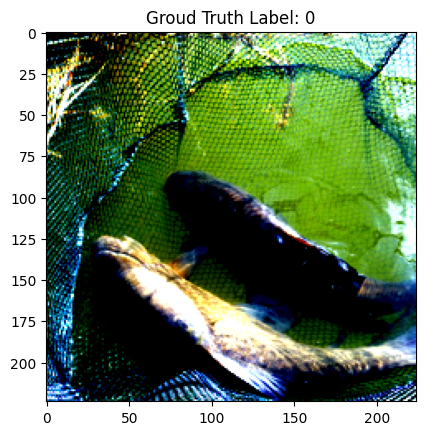

In [ ]:
import matplotlib.pyplot as plt

image, label = train_data[0]
plt.imshow(image.permute(1,2,0))
plt.title(f"Groud Truth Label: {label}")
plt.show()

# **3. EfficientNet-B0 모델 학습 설정**

In [ ]:
# WandB 연결
import os, wandb
from google.colab import userdata

os.environ["WANDB_API_KEY"] = userdata.get('WANDB_API_KEY')
wandb.login()

wandb_run = wandb.init(project = 'Image Classification',
                       notes = 'Eff-B0 w/o Data Aug',
                       name = 'Eff-B0 w/o Data Aug',)

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

device = 'cuda' if torch.cuda.is_available() else 'cpu'
learning_rate = 3e-4
batch_size = 64
epochs = 60

train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=6, drop_last=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=6)
num_batch = len(train_dataloader)

model = EfficientNet_B0(3, 10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=5e-4)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0 = 10 * num_batch, eta_min = 1e-5)

In [ ]:
from tqdm import tqdm

def train(model, criterion, optimizer, train_dataloader, val_dataloader, epochs, device, batch_size, scheduler):
    model.to(device)
    model.train()

    best_acc = 0
    print_call = len(train_dataloader) // 5

    for epoch in range(1, epochs+1):
        print(f"======== Epoch: {epoch} ========")
        train_loss = 0
        correct = 0
        data_num = 0
        step = 0
        for inputs, targets in tqdm(train_dataloader, desc=f"Epoch {epoch}/{epochs}"):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * targets.shape[0]

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == targets).sum().item()
            data_num += targets.shape[0]

            if step % print_call == 0:
                print(f"\tTrain Loss: {train_loss / data_num:.4f}, Train Acc: {correct/data_num*100:.2f}%")

            current_epoch = (epoch-1) + step / len(train_dataloader)

            log_dict = {
                "train/loss": loss.item(),
                "train/LR": scheduler.get_last_lr()[0],
                "epoch": current_epoch,
                }

            wandb.log(log_dict)

            step += 1
            scheduler.step()

        train_loss = train_loss / data_num
        train_acc = correct / data_num

        val_loss, val_acc = evaluation(model, criterion, val_dataloader, device, epoch)

        print(f"Epoch Summary({epoch}/{epochs}): Train Loss: {train_loss:.4f} // Val Loss: {val_loss:.4f} // Train Acc: {train_acc*100:.2f}% // Val Acc: {val_acc*100:.2f}%")

        if best_acc < val_acc:
                print(f"Best performance at epoch: {epoch}, {best_acc:.4f} -> {val_acc:.4f}\n")
                best_acc = val_acc
                torch.save(model.state_dict(), './best_model.pt')

def evaluation(model, criterion, val_dataloader, device, epoch):
    model.eval()
    correct = 0
    data_num = 0
    val_loss = 0

    with torch.no_grad():
        for inputs, targets in tqdm(val_dataloader, desc="Validation"):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            val_loss += loss * targets.shape[0]
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == targets).sum().item()
            data_num += targets.shape[0]

        val_loss = val_loss / data_num
        val_acc = correct / data_num

    log_dict = {
        "val/loss": val_loss,
        "val/val acc": val_acc,
        "epoch": epoch,
        }

    wandb.log(log_dict)

    model.train()
    return val_loss, val_acc

# **4. 학습 시작!**

In [ ]:
train(model = model,
      criterion = criterion,
      optimizer = optimizer,
      train_dataloader = train_dataloader,
      val_dataloader = val_dataloader,
      epochs = epochs,
      device = device,
      batch_size = batch_size,
      scheduler = scheduler)

In [ ]:
wandb.finish()

# **5. 학습 결과 (25.09)**

여러 차례 실험 후 가장 높게 나온 성능을 기록했습니다. (+ 다른 모델의 학습 결과도 비교를 위해 가져와봤습니다.)

| 실험 모델 | 데이터 증강 여부 | Validation Accuracy | 학습 상세 | 학습 시간 (L4 GPU) |
|-----------|------------------|:-------------------:|-----------|-----------|
| VGG-16-bn |&nbsp;&nbsp;&nbsp;&nbsp; X                | 83.2%               |lr=1e-4, batch_size=64, epochs=20, 10 에폭에서 lr 1/10로 감소| 60분 (3분/epoch) |
| VGG-16-bn |&nbsp;&nbsp;&nbsp;&nbsp; O (기본+좌우반전+색변화)               | 86.4%               |lr=1e-4, batch_size=64, epochs=14, 10 에폭에서 lr 1/10로 감소| 190분 (13.5분/epoch) |
| ResNet-50 |&nbsp;&nbsp;&nbsp;&nbsp; X                | 81.7%               |lr=2e-4, batch_size=32, epochs=10, ReduceLROnPlateau(factor=0.1, patience=2) 적용| 20분 (2분/epoch) |
| ResNet-50 |&nbsp;&nbsp;&nbsp;&nbsp; O (기본+좌우반전+색변화)               | 83.0%               |lr=1e-4, batch_size=32, epochs=15, 10 에폭에서 lr 1/10로 감소| 170분 (11.5분/epoch) |
| EfficientNet-B0 |&nbsp;&nbsp;&nbsp;&nbsp; X                | 78.6%               |lr=1e-3, batch_size=32, epochs=20, ReduceLROnPlateau(factor=0.1, patience=2) 적용| 35분 (1.75분/epoch) |
| EfficientNet-B0 |&nbsp;&nbsp;&nbsp;&nbsp; O (기본+좌우반전+색변화)               | 83.2%               |lr=1e-3, batch_size=64, epochs=14, ReduceLROnPlateau(factor=0.1, patience=2) 적용| 140분 (10분/epoch) |

# **6. 재학습 결과 (26.01)**
**⚠️주의**: 학습 데이터셋은 **Imagenette**으로, ImageNet의 축소 버전입니다.  

[적용한 데이터 증강]
- RandomHorizontalFlip(p=0.5)
- ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)

| No. | 실험 모델 | 파라미터 | 증강 | Val Acc | 학습 상세 | 학습 시간 (L4 GPU) |
|:---:|:--------:|:---------:|:----:|:-------:|:---------:|:------------------:|
| 1 | VGG16         | 138M | X | 78.98%    |LR=1e-4, Batch_size=64, Epochs=60 | 92분 (1.5분/Epoch) |
| 2 | VGG16         | 138M | O | 82.37%    |LR=1e-4, Batch_size=64, Epochs=60 | 92분 (1.5분/Epoch)|
| 3 | ResNet-50 | 25M | X | 86.93% |LR=1e-4, Batch_size=64, Epochs=60 | 57분 (1분/Epoch)|
| 4 | ResNet-50 | 25M | O | 87.34% |LR=1e-4, Batch_size=64, Epochs=60 | 57분 (1분/Epoch)|
| 5 | **EfficientNet-B0** | 5.3M | X | **85.61%** |LR=3e-4, Batch_size=64, Epochs=60 | 36분 (0.6분/Epoch)|
| 6 | **EfficientNet-B0** | 5.3M | O | **87.80%** |LR=3e-4, Batch_size=64, Epochs=60 | 36분 (0.6분/Epoch)|
| 7 | VGG16-bn      | 138M | X | 89.71%    |LR=1e-4, Batch_size=64, Epochs=60 | 112분 (1.9분/Epoch)|
| 8 | VGG16-bn      | 138M | O | 90.75%    |LR=1e-4, Batch_size=64, Epochs=60 | 112분 (1.9분/Epoch)|

증강 여부를 기준으로 정렬하면 다음과 같습니다.

| No. | 실험 모델 | 파라미터 | 증강 | Val Acc | 학습 상세 | 학습 시간 (L4 GPU) |
|:---:|:---------:|:--------:|:----:|:-------:|:---------:|:------------------:|
| 1 | VGG-16    | 138M | X | 78.98% |LR=1e-4, Batch_size=64, Epochs=60 | 92분 (1.5분/Epoch) |
| 2 | ResNet-50 | 25M | X | 86.93% |LR=1e-4, Batch_size=64, Epochs=60 | 57분 (1분/Epoch)|
| 3 | **EfficientNet-B0** | 5.3M | X | **85.61%** |LR=3e-4, Batch_size=64, Epochs=60 | 36분 (0.6분/Epoch)|
| 4 | VGG-16-bn | 138M | X | 89.71% |LRr=1e-4, Batch_size=64, Epochs=60 | 112분 (1.9분/Epoch)|
|||||||
| 5 | VGG-16    | 138M | O | 82.37% |LR=1e-4, Batch_size=64, Epochs=60 | 92분 (1.5분/Epoch)|
| 6 | ResNet-50 | 25M | O | 87.34% |LR=1e-4, Batch_size=64, Epochs=60 | 57분 (1분/Epoch)|
| 7 | **EfficientNet-B0** | 5.3M | O | **87.80%** |LR=3e-4, Batch_size=64, Epochs=60 | 36분 (0.6분/Epoch)|
| 8 | VGG-16-bn | 138M | O | 90.75% |LR=1e-4, Batch_size=64, Epochs=60 | 112분 (1.9분/Epoch)|


# **7. 로그, 모델 저장 및 불러오기**

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
model_path  = "./best_model.pt"
save_path   = '/content/drive/MyDrive/Colab_Notebooks/Boost Camp AI Tech/구현/model/Eff-B0_No_Augment.pt'

In [ ]:
# 모델 저장하기
import shutil

shutil.copy(model_path, save_path)

In [ ]:
# 모델 불러오기
pretrained_model = EfficientNet_B0(3,10)
pretrained_model.load_state_dict(torch.load(save_path, map_location='cuda')) # GPU를 사용하고 있다면 'cuda'로 설정하시길!
pretrained_model.eval()